C:\Users\Jayanth C R\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1127/1127 ━━━━━━━━━━━━━━━━━━━━ 1s 763us/step 
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 1s 725us/step
Accuracy with relu: 77.59%


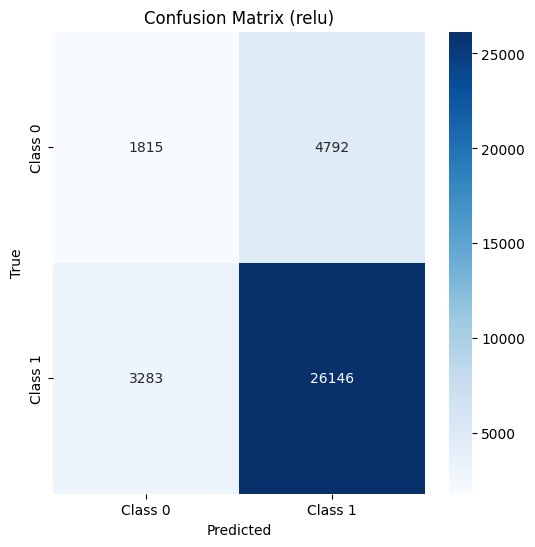

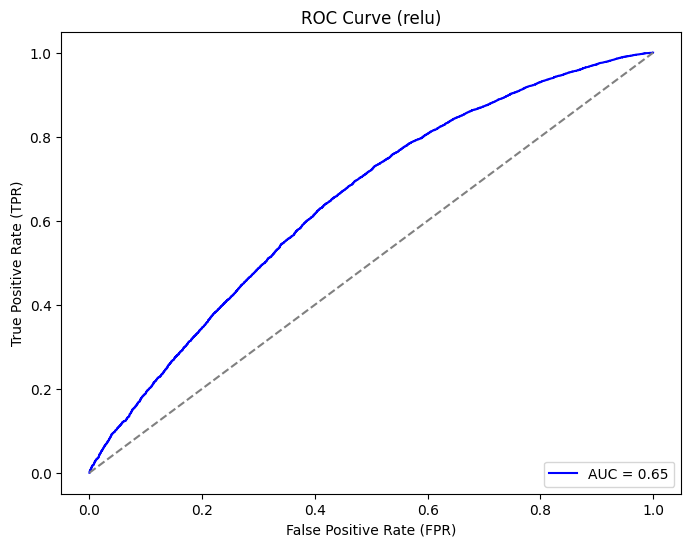

C:\Users\Jayanth C R\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1127/1127 ━━━━━━━━━━━━━━━━━━━━ 1s 774us/step
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 1s 731us/step
Accuracy with tanh: 76.64%


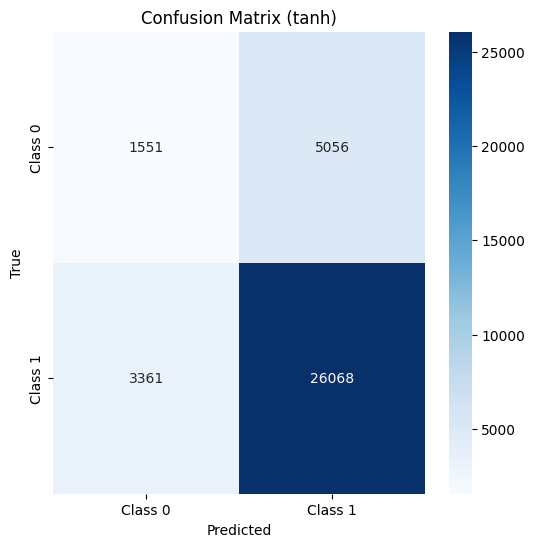

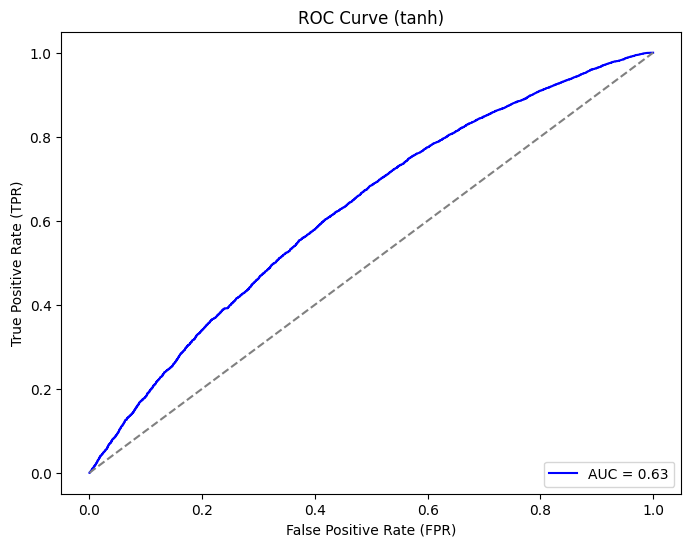

C:\Users\Jayanth C R\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
C:\Users\Jayanth C R\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1127/1127 ━━━━━━━━━━━━━━━━━━━━ 1s 767us/step 
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 1s 720us/step
Accuracy with <LeakyReLU name=leaky_re_lu, built=True>: 78.05%


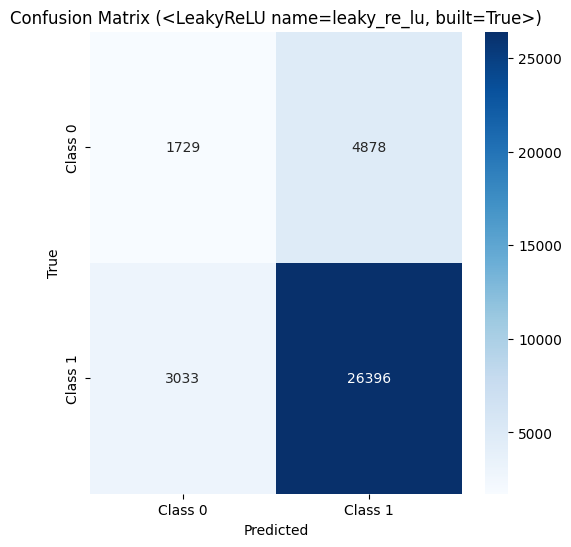

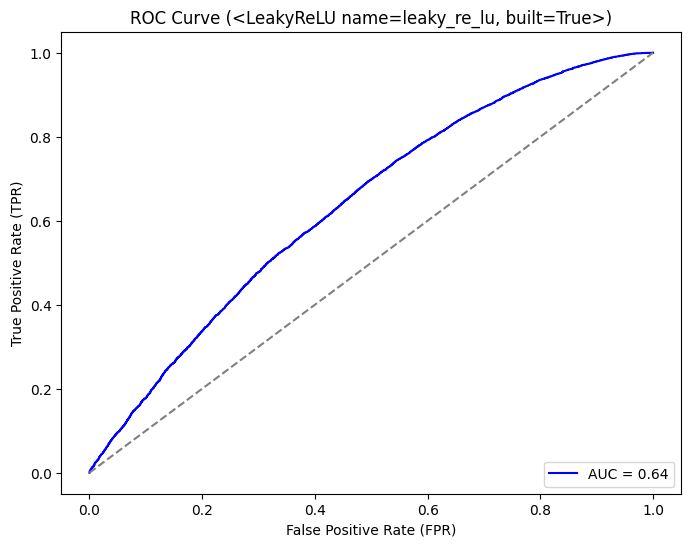

In [3]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc
from keras.models import Sequential
from keras.layers import Dense, LeakyReLU, BatchNormalization
from keras.optimizers import Adam
from keras.utils import to_categorical

# Define base directory (make sure to change it to your dataset path)
BASE_DIR = r"D:\Amrita\Sem-4\Machine Learning Lab\End Sem Project\Excel\5. Splitting"

def load_data():
    files = ["X_train.csv", "y_train.csv", "X_test.csv", "y_test.csv"]
    file_paths = {file: os.path.join(BASE_DIR, file) for file in files}

    # Check if files exist
    for file, path in file_paths.items():
        if not os.path.exists(path):
            raise FileNotFoundError(f"Error: {file} not found in {BASE_DIR}")

    # Load data
    X_train = pd.read_csv(file_paths["X_train.csv"])
    y_train = pd.read_csv(file_paths["y_train.csv"]).values.ravel()
    X_test = pd.read_csv(file_paths["X_test.csv"])
    y_test = pd.read_csv(file_paths["y_test.csv"]).values.ravel()

    return X_train, y_train, X_test, y_test

def preprocess_data(X_train, X_test):
    # Ensure that both X_train and X_test have the same columns
    X_test = X_test[X_train.columns]  # Align test data columns with train data

    # Standardizing the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train_scaled, X_test_scaled

def build_model(input_dim, activation_function):
    model = Sequential()
    model.add(Dense(64, input_dim=input_dim, activation=activation_function))
    model.add(BatchNormalization())
    model.add(Dense(32, activation=activation_function))
    model.add(Dense(16, activation=activation_function))
    model.add(Dense(1, activation='sigmoid'))  # Binary classification output

    model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

def plot_roc_curve(y_true, y_pred_prob, title="ROC Curve"):
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    auc_score = auc(fpr, tpr)
    
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, color='b', label=f'AUC = {auc_score:.2f}')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.title(title)
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.legend(loc="lower right")
    plt.show()

def train_evaluate_model(activation_function):
    # Load and preprocess data
    X_train, y_train, X_test, y_test = load_data()
    X_train_scaled, X_test_scaled = preprocess_data(X_train, X_test)
    
    # Build and train the model
    model = build_model(X_train_scaled.shape[1], activation_function)
    model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_data=(X_test_scaled, y_test), verbose=0)

    # Evaluate the model
    y_pred = (model.predict(X_test_scaled) > 0.5).astype("int32")  # Predictions as binary (0 or 1)
    y_pred_prob = model.predict(X_test_scaled)  # Probabilities for ROC curve

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy with {activation_function}: {accuracy * 100:.2f}%")
    
    # Confusion Matrix
    plot_confusion_matrix(y_test, y_pred, title=f"Confusion Matrix ({activation_function})")
    
    # ROC Curve
    plot_roc_curve(y_test, y_pred_prob, title=f"ROC Curve ({activation_function})")

# Train and evaluate with different activation functions
for activation in ['relu', 'tanh']:
    train_evaluate_model(activation)

# With Leaky ReLU
train_evaluate_model(LeakyReLU(alpha=0.01))  # Alpha can be adjusted based on the model behavior
